# Client personality analysis
Author: David Moncivais | August 4 2026

## Introduction

### Objective
The objective of this project is to use the available data — a list of customers with different attributes — and cluster the information to summarize customer segments. A secondary objective, as with previous projects, is to use it as a practice exercise for data presentation, feature engineering, model selection, hyperparameter tuning, and the interpretation of results through data visualization.

Customer personality analysis helps a business to modify its product based on its target customers from different types of customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.  It helps a business to better understand its customers and makes it easier for them to modify products according to the specific needs, behaviors and concerns of different types of customers. 

### The data
The data is a dataset of 2240 rows of individual customers, where each feature column is part of a simplified group of characteristics for each customer. The groups are: People, Products, Promotion, and Place. The dataset description give use the next glossary of the columns needed to look at for the experiment:
- People
    - ID: Customer's unique identifier
    - Year_Birth: Customer's birth year
    - Education: Customer's education level
    - Marital_Status: Customer's marital status
    - Income: Customer's yearly household income
    - Kidhome: Number of children in customer's household
    - Teenhome: Number of teenagers in customer's household
    - Dt_Customer: Date of customer's enrollment with the company
    - Recency: Number of days since customer's last purchase
    - Complain: 1 if the customer complained in the last 2 years, 0 otherwise
- Products
    - MntWines: Amount spent on wine in last 2 years
    - MntFruits: Amount spent on fruits in last 2 years
    - MntMeatProducts: Amount spent on meat in last 2 years
    - MntFishProducts: Amount spent on fish in last 2 years
    - MntSweetProducts: Amount spent on sweets in last 2 years
    - MntGoldProds: Amount spent on gold in last 2 years
- Promotion
    - NumDealsPurchases: Number of purchases made with a discount
    - AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
    - AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
    - AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
    - AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
    - AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
    - Response: 1 if customer accepted the offer in the last campaign, 0 otherwise
- Place
    - NumWebPurchases: Number of purchases made through the company’s website
    - NumCatalogPurchases: Number of purchases made using a catalogue
    - NumStorePurchases: Number of purchases made directly in stores
    - NumWebVisitsMonth: Number of visits to company’s website in the last month

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
base_columns = ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Complain', 'MntWines', 'MntFruits',
                'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
                'AcceptedCmp5', 'Response', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
df = pd.read_csv('./Data/marketing_campaign.csv', sep='\t')[base_columns]
print('Number of columns: ' + str(len(base_columns)) + '\nNumber of data entries: ' + str(len(df['ID'])))

Number of columns: 26
Number of data entries: 2240


In [3]:
for i in range(3):
    display(df[base_columns[i*9:(i*9)+9]].head(5))

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain
0,5524,1957,Graduation,Single,58138.0,0,0,58,0
1,2174,1954,Graduation,Single,46344.0,1,1,38,0
2,4141,1965,Graduation,Together,71613.0,0,0,26,0
3,6182,1984,Graduation,Together,26646.0,1,0,26,0
4,5324,1981,PhD,Married,58293.0,1,0,94,0


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,AcceptedCmp1,AcceptedCmp2
0,635,88,546,172,88,88,3,0,0
1,11,1,6,2,1,6,2,0,0
2,426,49,127,111,21,42,1,0,0
3,11,4,20,10,3,5,2,0,0
4,173,43,118,46,27,15,5,0,0


,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0,0,0,1,8,10,4,7
1,0,0,0,0,1,1,2,5
2,0,0,0,0,8,2,10,4
3,0,0,0,0,2,0,4,6
4,0,0,0,0,5,3,6,5


In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,0.009375,303.935714,26.302232,166.950000,...,0.064286,0.013393,0.072768,0.074554,0.072768,0.149107,4.084821,2.662054,5.790179,5.316518
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,0.096391,336.597393,39.773434,225.715373,...,0.245316,0.114976,0.259813,0.262728,0.259813,0.356274,2.778714,2.923101,3.250958,2.426645
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,0.000000,23.750000,1.000000,16.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000,3.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,0.000000,173.500000,8.000000,67.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2.000000,5.000000,6.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,0.000000,504.250000,33.000000,232.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,8.000000,7.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1.000000,1493.000000,199.000000,1725.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,27.000000,28.000000,13.000000,20.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Recency              2240 non-null   int64  
 8   Complain             2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.isnull().mean() * 100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Recency                0.000000
Complain               0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
Response               0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
dtype: float64

In [7]:
df['Income'] = df['Income'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Recency              2240 non-null   int64  
 8   Complain             2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
i = 0
r_camp = []
r_age = []
for row in df.itertuples():
    try: r_camp.append(row[18:24].index(1)+1)
    except: r_camp.append(0)
    r_age.append(2026 - int(row[2]))
df['Campagin'] = r_camp
df['Age'] = r_age
df = df.drop(['Year_Birth'], axis=1)
df = df.drop(['AcceptedCmp'+str(i) for i in range(1,6)]+['Response'], axis=1)
df

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,Complain,MntWines,MntFruits,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Campagin,Age
0,5524,Graduation,Single,58138.0,0,0,58,0,635,88,...,172,88,88,3,8,10,4,7,5,69
1,2174,Graduation,Single,46344.0,1,1,38,0,11,1,...,2,1,6,2,1,1,2,5,6,72
2,4141,Graduation,Together,71613.0,0,0,26,0,426,49,...,111,21,42,1,8,2,10,4,0,61
3,6182,Graduation,Together,26646.0,1,0,26,0,11,4,...,10,3,5,2,2,0,4,6,0,42
4,5324,PhD,Married,58293.0,1,0,94,0,173,43,...,46,27,15,5,5,3,6,5,0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,Graduation,Married,61223.0,0,1,46,0,709,43,...,42,118,247,2,9,3,4,5,0,59
2236,4001,PhD,Together,64014.0,2,1,56,0,406,0,...,0,0,8,7,8,2,5,7,0,80
2237,7270,Graduation,Divorced,56981.0,0,0,91,0,908,48,...,32,12,24,1,2,3,13,6,3,45
2238,8235,Master,Together,69245.0,0,1,8,0,428,30,...,80,30,61,2,6,5,10,3,0,70


In [9]:
def distribution_graph_simple(df: pd.DataFrame(), x_label: str = '', y_label: list[str] = ['']):
    b_min = min(df[x_label])
    b_max = max(df[x_label]) % 5
    b_max = max(df[x_label]) if b_max == 0 else max(df[x_label]) + (5 - b_max)
    lst_bin = [i for i in range(b_min, b_max+1, 5)]
    bins = pd.cut(df[x_label], bins=lst_bin, right=False)
    df_pct = df_sort[cols].div(df_sort[cols].sum(axis=1), axis=0) * 100
    df_pct_avg = df_pct.groupby(bins).mean().reset_index()

    bottom = None
    plt.figure(figsize=(13,8))
    for col in y_label:
        bars = plt.bar(df_pct_avg[x_label].astype(str), df_pct_avg[col], bottom=bottom, label=col)
        for bar, val, b in zip(bars, df_pct_avg[col], bottom if bottom is not None else [0]*len(bars)):
            plt.text(bar.get_x()+bar.get_width()/2, b+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8)
        if bottom is None:
            bottom = df_pct_avg[col].copy()
        else:
            bottom += df_pct_avg[col]
    
    plt.yticks([i for i in range(5,101,5)])
    
    plt.xlabel('Ranges of ' + x_label)
    plt.ylabel('% of total amount')
    plt.title('According to ' + x_label + ', What is what clients want? (Ranges)')
    
    plt.legend()
    plt.show()

def distribution_graph_detailed(df: pd.DataFrame(), x_label: str = '', y_label: list[str] = ['']):
    df_pct = df[y_label].div(df[y_label].sum(axis=1), axis=0) * 100
    df_pct_avg = df_pct.groupby(df[x_label]).mean().reset_index()

    bottom = None
    plt.figure(figsize=(13,8))
    for col in y_label:
        plt.bar(df_pct_avg[x_label], df_pct_avg[col], bottom=bottom, label=col)
        if bottom is None:
            bottom = df_pct_avg[col].copy()
        else:
            bottom += df_pct_avg[col]
    
    plt.yticks([i for i in range(5,101,5)])
    
    plt.xlabel(x_label)
    plt.ylabel('% of total amount')
    plt.title('According to ' + x_label + ', What is what clients want?')

    plt.legend()
    plt.show()

In [10]:
print(df['Education'].unique())

['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']


In [11]:
print(df['Marital_Status'].unique())

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [12]:
df_clients = df[['ID', 'Age']].groupby('ID', as_index = False).count()
df_clients[df_clients['Age'] > 1]

,ID,Age


In [13]:
df_sort = df.sort_values(by = 'Age')[df['Age'] <100]
print('Youngest client: ' + str(df_sort['Age'].iloc[0]) + ', Oldest client: ' + str(df_sort['Age'].iloc[-1]))

Youngest client: 30, Oldest client: 86


C:\Users\david\AppData\Local\Temp\ipykernel_25420\3223006078.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_sort = df.sort_values(by = 'Age')[df['Age'] <100]


In [14]:
cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_sort[['Age'] + cols].head(5)

,Age,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
46,30,3,18,14,15,22,50
1170,30,0,0,2,3,3,8
2213,31,594,51,631,72,55,32
747,31,283,17,372,138,106,44
1850,31,536,27,590,38,107,67


C:\Users\david\AppData\Local\Temp\ipykernel_25420\461274552.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


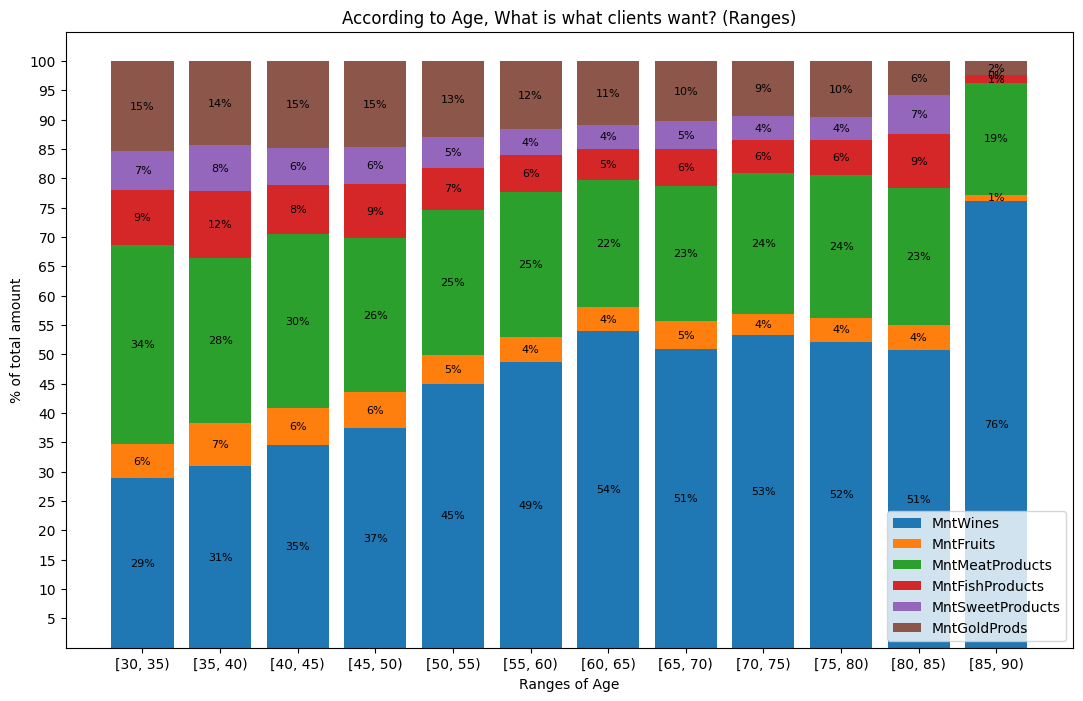

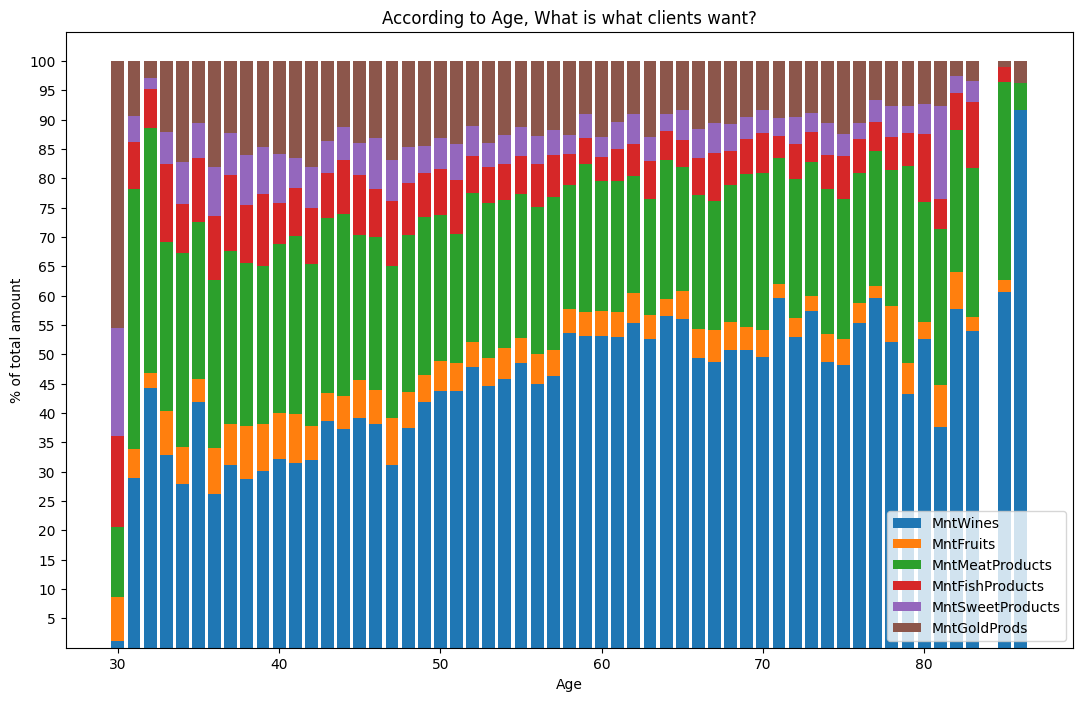

In [15]:
distribution_graph_simple(df_sort, 'Age', cols)
distribution_graph_detailed(df_sort, 'Age', cols)

In [16]:
cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df[['Age'] + cols].head(5)

,Age,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
0,69,8,10,4
1,72,1,1,2
2,61,8,2,10
3,42,2,0,4
4,45,5,3,6


C:\Users\david\AppData\Local\Temp\ipykernel_25420\461274552.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pct_avg = df_pct.groupby(bins).mean().reset_index()


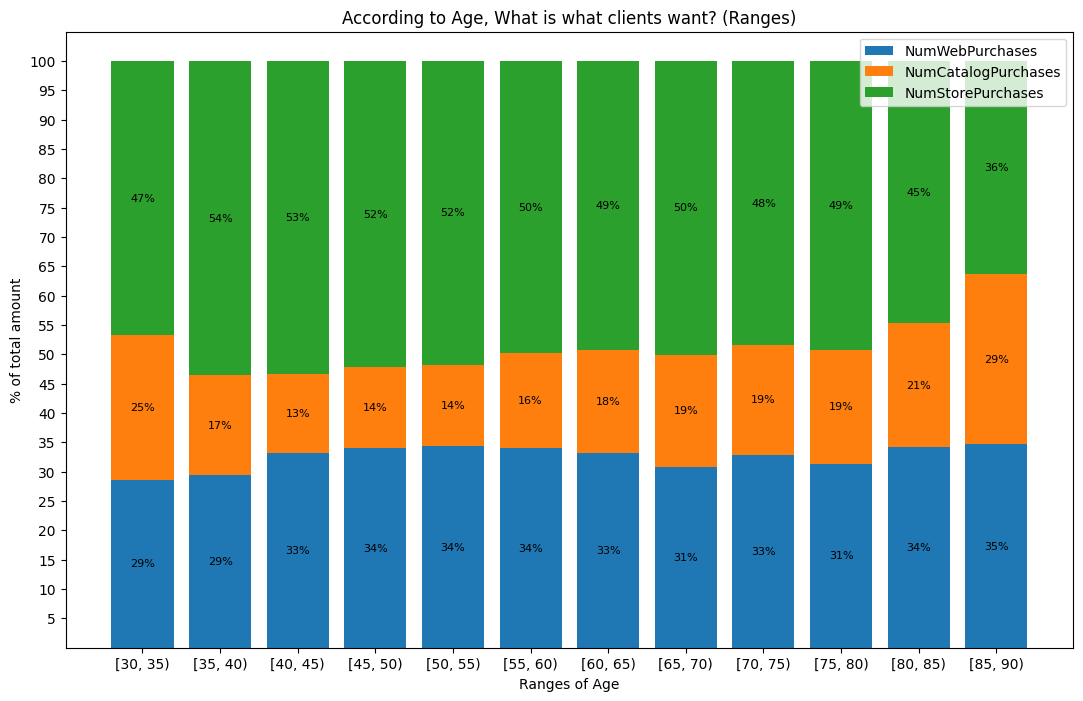

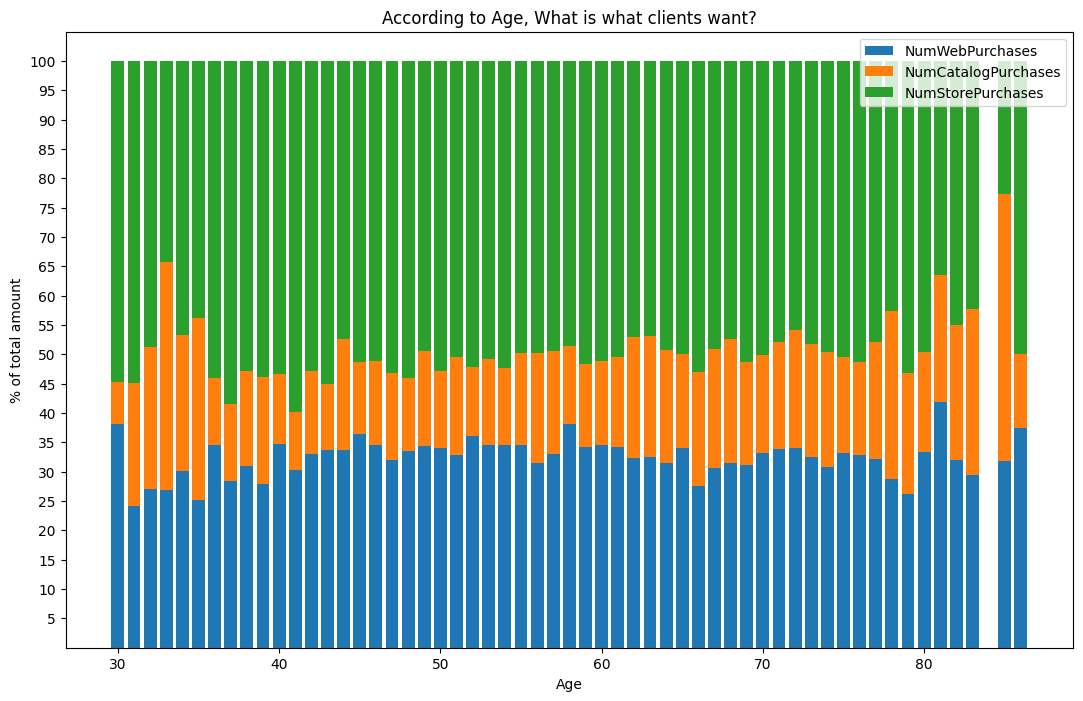

In [17]:
distribution_graph_simple(df_sort, 'Age', cols)
distribution_graph_detailed(df_sort, 'Age', cols)

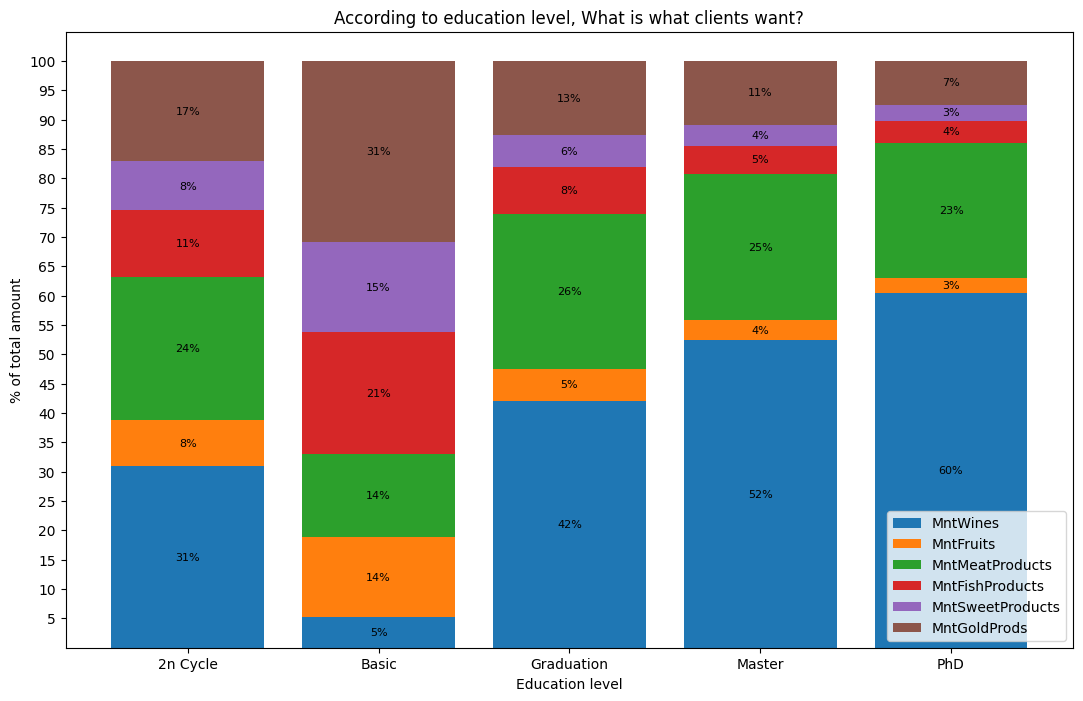

In [20]:
cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
education = df['Education']
df_pct = df_sort[cols].div(df_sort[cols].sum(axis=1), axis=0) * 100
df_pct_avg = df_pct.groupby(education).mean().reset_index()
bottom = None
plt.figure(figsize=(13,8))
for col in cols:
    bars = plt.bar(df_pct_avg['Education'], df_pct_avg[col], bottom=bottom, label=col)
    b_vals = bottom if bottom is not None else pd.Series([0]*len(bars))
    for bar, val, b in zip(bars, df_pct_avg[col], b_vals):
        plt.text(bar.get_x()+bar.get_width()/2, b+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8)
    if bottom is None:
        bottom = df_pct_avg[col].copy()
    else:
        bottom += df_pct_avg[col]
        
plt.yticks([i for i in range(5,101,5)])
    
plt.xlabel('Education level')
plt.ylabel('% of total amount')
plt.title('According to education level, What is what clients want?')

plt.legend()
plt.show()

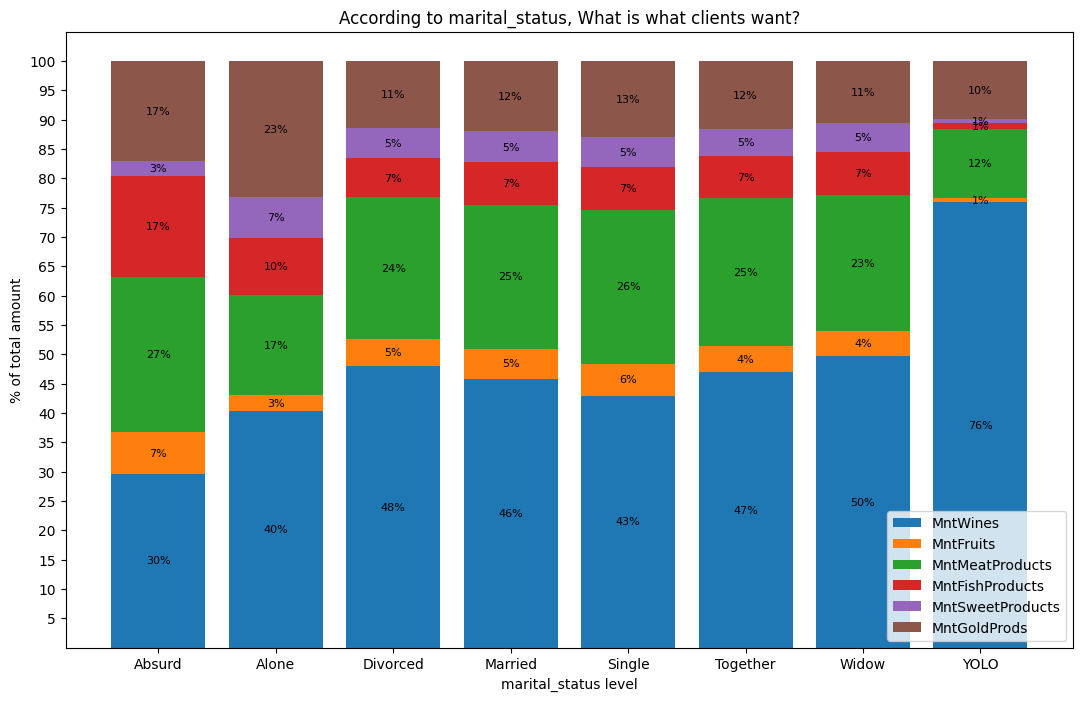

In [22]:
cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
marital_status = df['Marital_Status']
df_pct = df_sort[cols].div(df_sort[cols].sum(axis=1), axis=0) * 100
df_pct_avg = df_pct.groupby(marital_status).mean().reset_index()
bottom = None
plt.figure(figsize=(13,8))
for col in cols:
    bars = plt.bar(df_pct_avg['Marital_Status'], df_pct_avg[col], bottom=bottom, label=col)
    b_vals = bottom if bottom is not None else pd.Series([0]*len(bars))
    for bar, val, b in zip(bars, df_pct_avg[col], b_vals):
        plt.text(bar.get_x()+bar.get_width()/2, b+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=8)
    if bottom is None:
        bottom = df_pct_avg[col].copy()
    else:
        bottom += df_pct_avg[col]
        
plt.yticks([i for i in range(5,101,5)])
    
plt.xlabel('marital_status level')
plt.ylabel('% of total amount')
plt.title('According to marital_status, What is what clients want?')

plt.legend()
plt.show()